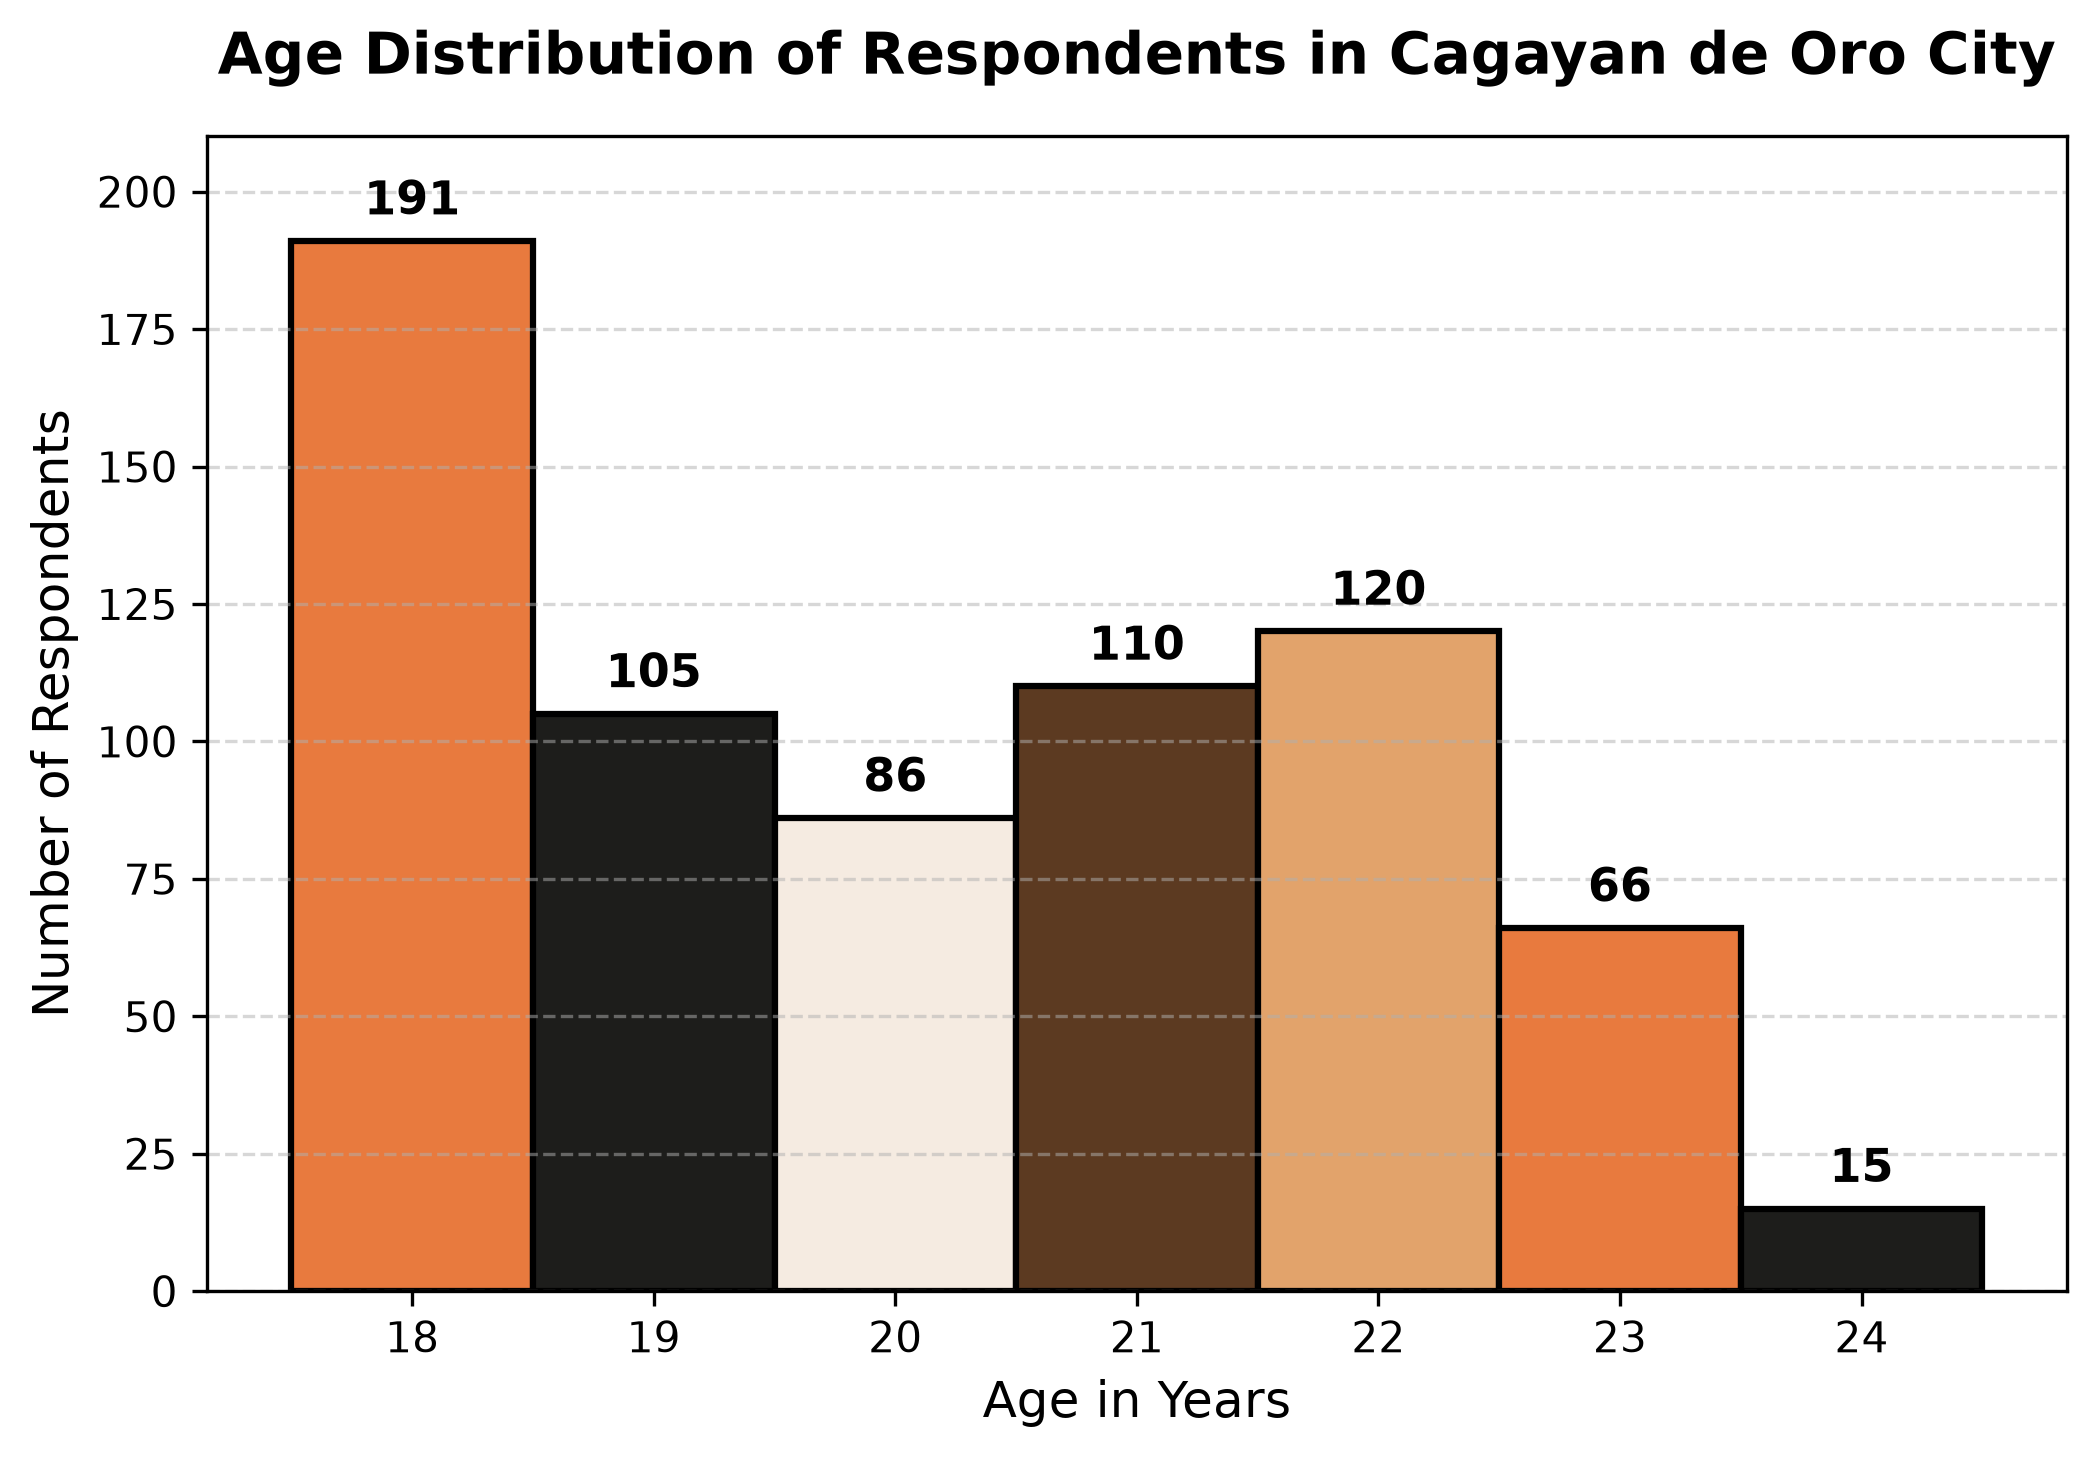

Success! The Calico chart with numbers has been saved to: data_visualization\Age_Distribution.png


In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the cleaned data
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
ages = cleaned_df['Age'].dropna()

# 2. Set up the high-resolution figure
plt.figure(figsize=(8, 5), dpi=300)

calico_colors = ['#E87A3E', '#1D1D1B', '#F5EBE1', '#5C3A21', '#E2A36B']

min_age = int(ages.min())
max_age = int(ages.max())
exact_bins = np.arange(min_age, max_age + 2) - 0.5

# 3. Create the histogram
n, bins, patches = plt.hist(ages, bins=exact_bins, edgecolor='black', linewidth=1.5)

# --- NEW: Give the chart 10% more breathing room at the top so text isn't cut off ---
plt.ylim(0, max(n) * 1.1)

# 4. Loop through each bar to color it AND add the text
for i, patch in enumerate(patches):
    # Set the Calico color
    patch.set_facecolor(calico_colors[i % len(calico_colors)])

    # Get the height of the bar (which is the actual count of people)
    count = int(patch.get_height())

    # Only add text if the bar actually has people in it
    if count > 0:
        # Find the center-top point of the bar
        x_center = patch.get_x() + patch.get_width() / 2

        # --- NEW: Add the text number ---
        # (max(n) * 0.015) pushes the text slightly above the bar so it's readable
        plt.text(
            x_center,
            count + (max(n) * 0.015),
            str(count),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='black',
        )

plt.xticks(range(min_age, max_age + 1))
plt.title("Age Distribution of Respondents in Cagayan de Oro City", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Age in Years", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Age_Distribution.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Success! The Calico chart with numbers has been saved to: {file_path}")

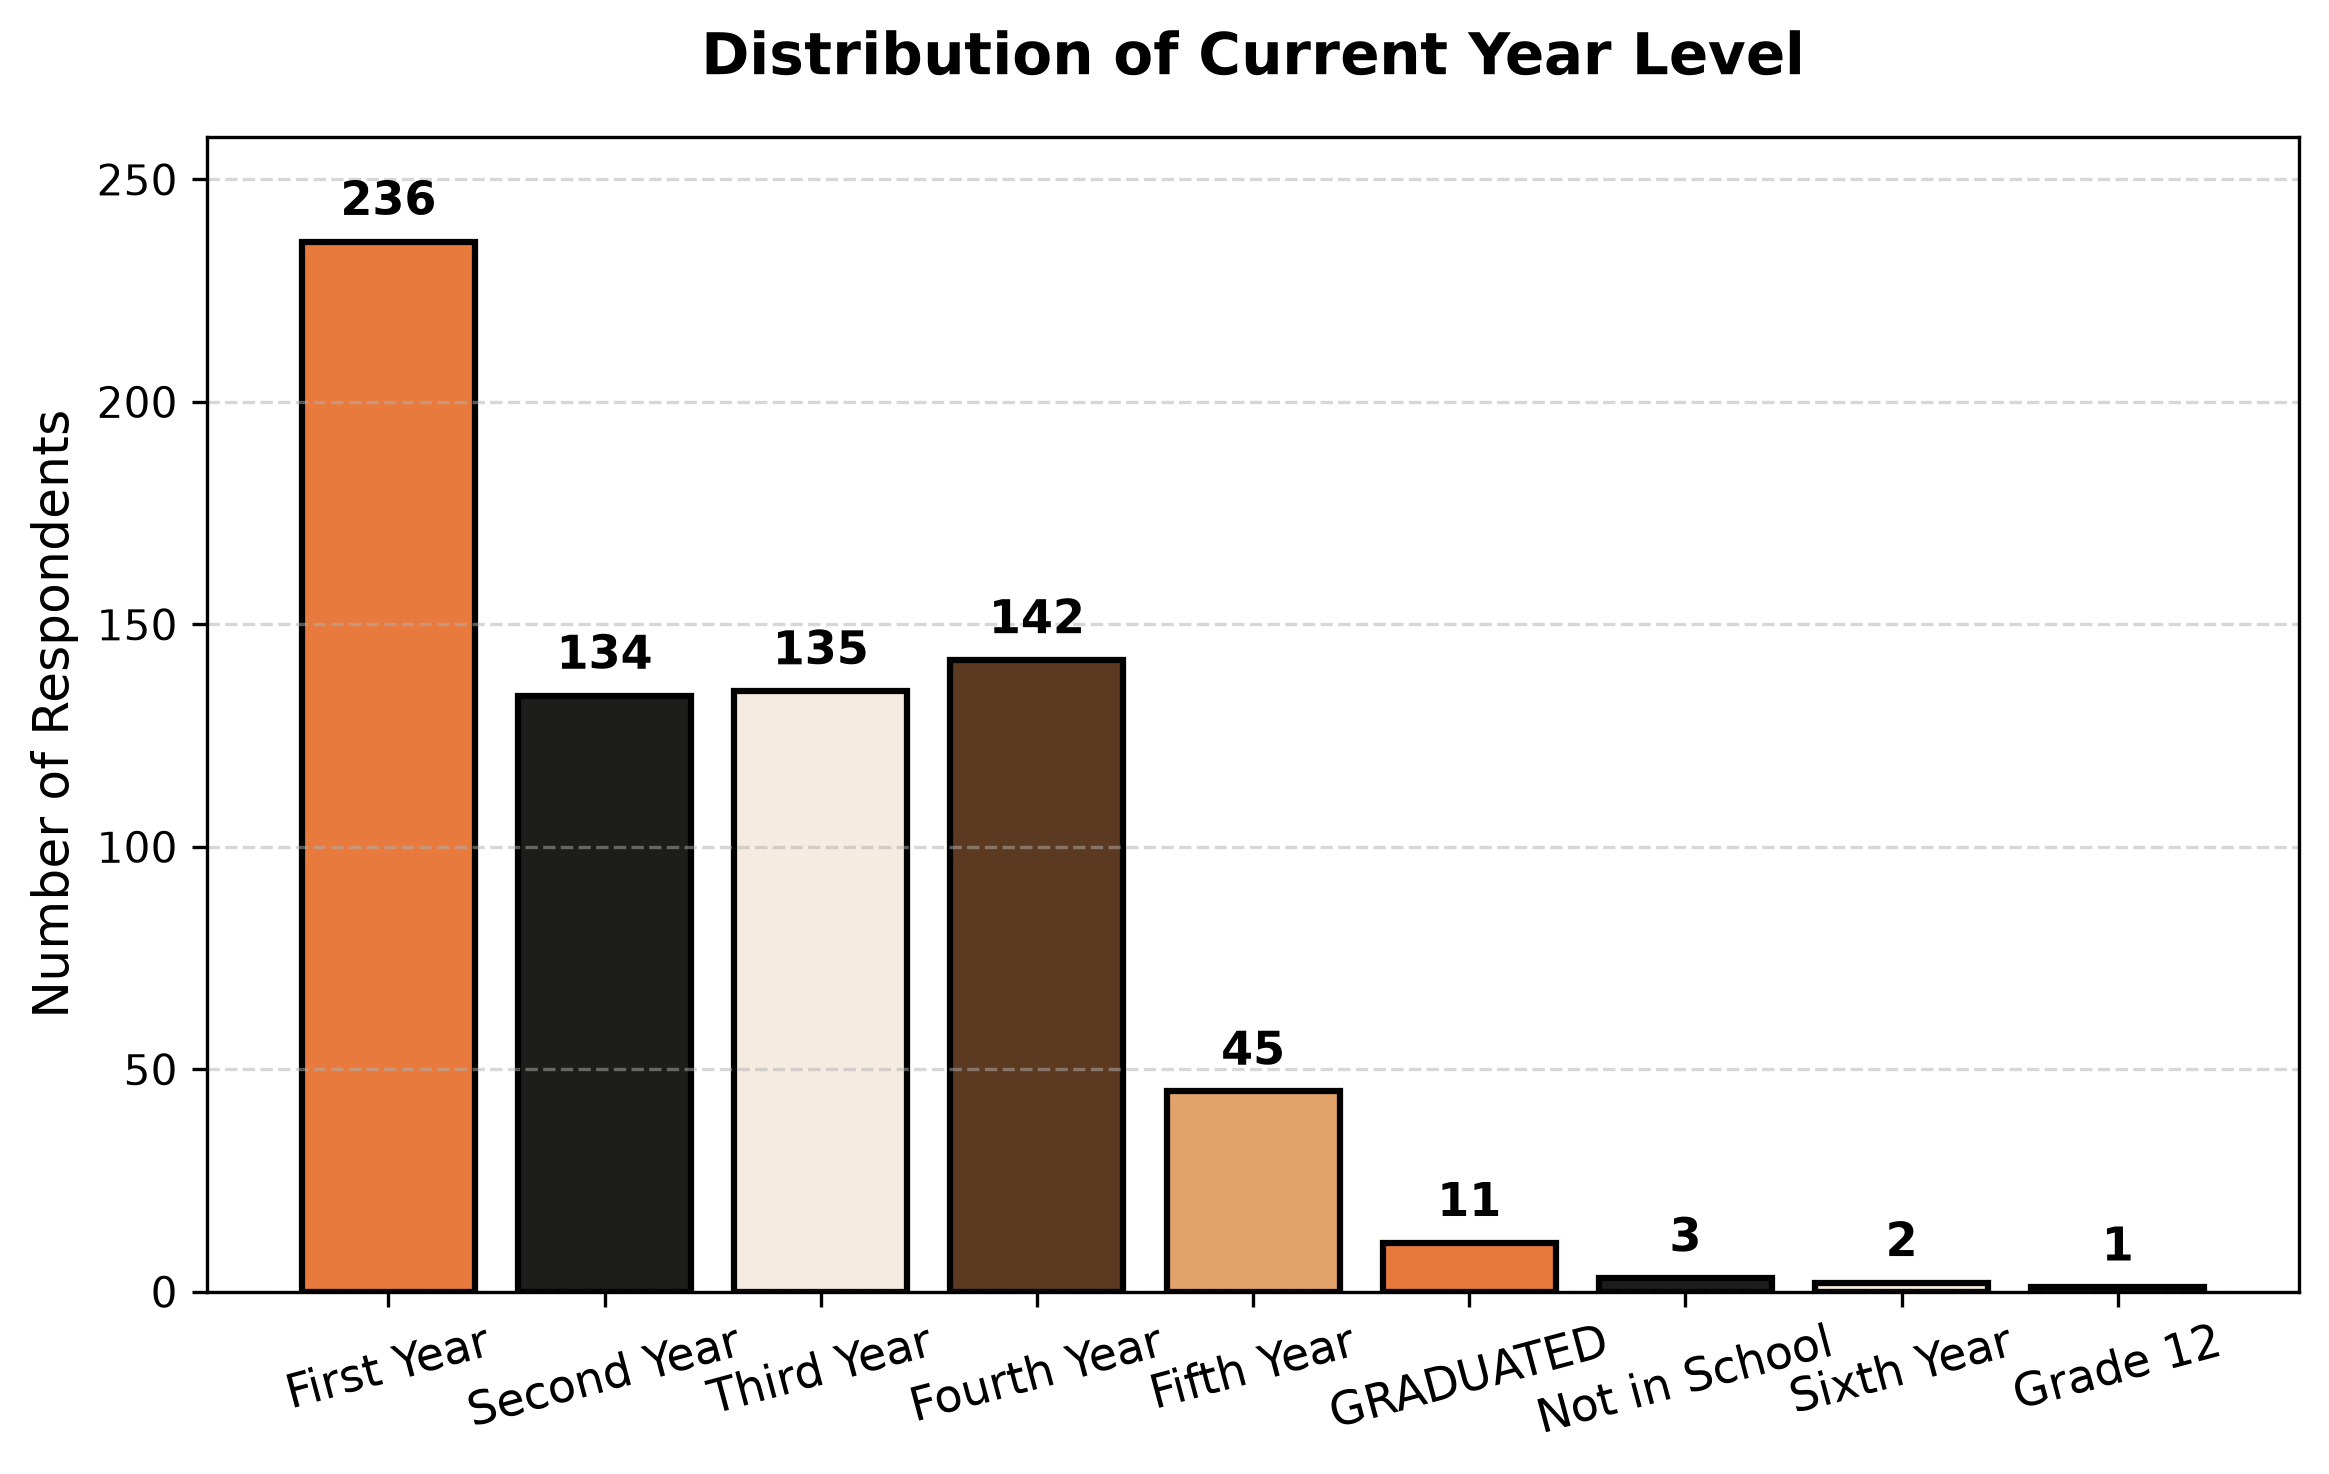

Success! The Year Level chart has been saved to: data_visualization\Year_Level_Distribution.png


In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the data and grab Column 5
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
year_col = cleaned_df.columns[5]

# Count the respondents for each year level
counts = cleaned_df[year_col].value_counts()

# --- PRO TRICK: FORCE LOGICAL ORDER ---
# Pandas usually sorts from biggest to smallest. We want chronological order!
correct_order = [
    "First Year",
    "Second Year",
    "Third Year",
    "Fourth Year",
    "Forth Year",
    "Fifth Year",
    "Not Specified",
    "TESDA",
]

# Filter our list to only include answers that actually exist in your data, in the correct order
ordered_labels = [level for level in correct_order if level in counts.index]
# Add any unexpected answers to the end
ordered_labels += [level for level in counts.index if level not in correct_order]

# Re-sort our counts to match this perfect logical order
counts = counts.reindex(ordered_labels)

# 2. Set up the figure
plt.figure(figsize=(9, 5), dpi=300)

calico_colors = ['#E87A3E', '#1D1D1B', '#F5EBE1', '#5C3A21', '#E2A36B']
# Loop the colors to match however many bars we have
colors = [calico_colors[i % len(calico_colors)] for i in range(len(counts))]

# 3. Create the Bar Chart
bars = plt.bar(
    counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5
)

# Give it 10% breathing room at the top
plt.ylim(0, counts.max() * 1.1)

# 4. Add the exact numbers on top of the bars!
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (counts.max() * 0.015),
            str(int(height)),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
        )

# 5. Add academic labels
plt.title(
    "Distribution of Current Year Level",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.ylabel("Number of Respondents", fontsize=12)

# Tilt the x-axis labels slightly if they are too long
plt.xticks(rotation=15, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Year_Level_Distribution.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Success! The Year Level chart has been saved to: {file_path}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_125648\2892606101.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


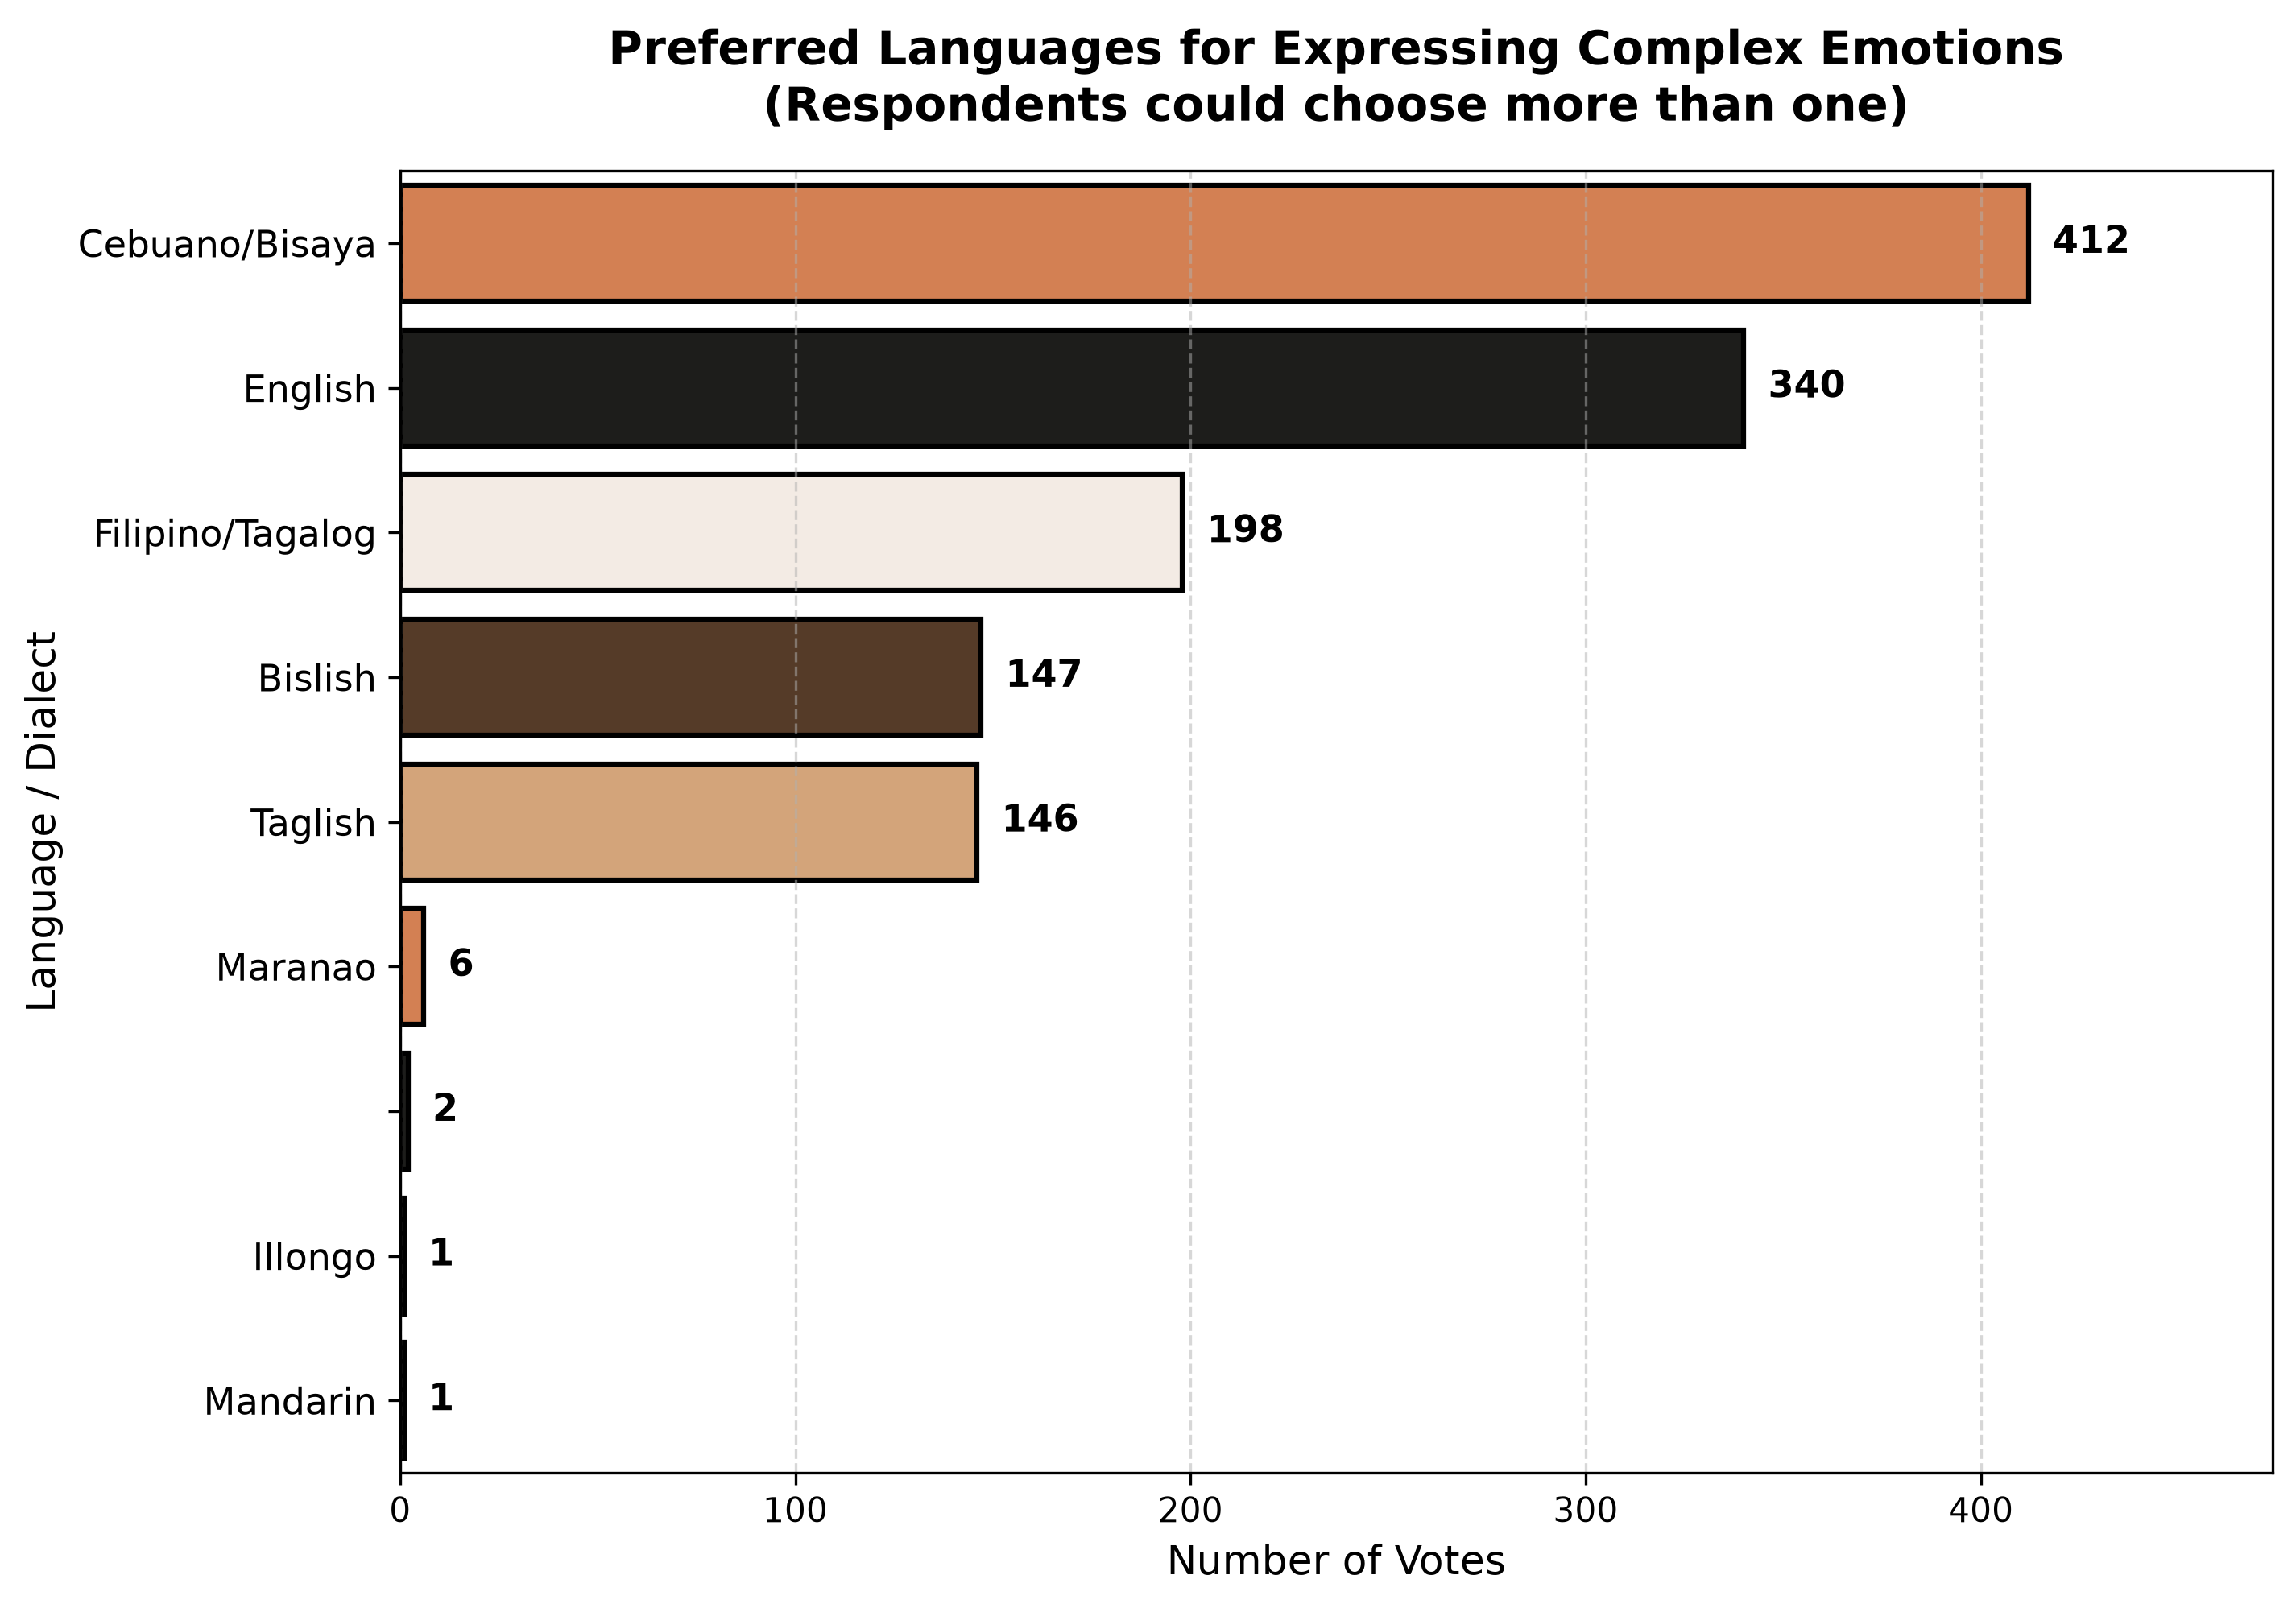

Success! The Language Preferences chart has been saved to: data_visualization\Language_Preferences.png


In [16]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the data and grab Column 7 (Index 6)
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
lang_col = cleaned_df.columns[6]

# 2. SPLIT THE MULTIPLE ANSWERS
separated_languages = (
    cleaned_df[lang_col]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
)

# 3. Clean up any accidental spaces
separated_languages = separated_languages.str.strip()

# 4. Count the individual languages
language_counts = separated_languages.value_counts().reset_index()
language_counts.columns = ["Language", "Count"]

# 5. Set up the figure with High Resolution
plt.figure(figsize=(10, 7), dpi=300)

# The Calico Theme Palette
calico_colors = ["#E87A3E", "#1D1D1B", "#F5EBE1", "#5C3A21", "#E2A36B"]
# Loop the colors to match however many bars we have in case there are a lot of languages
colors = [calico_colors[i % len(calico_colors)] for i in range(len(language_counts))]

# 6. Create the Horizontal Bar Chart using Seaborn
ax = sns.barplot(
    data=language_counts,
    x="Count",
    y="Language",
    palette=colors,
    edgecolor="black",  # Adds the Calico-style black borders
    linewidth=1.5,
)

# Give it 15% breathing room on the right side so our numbers fit nicely
max_count = language_counts["Count"].max()
plt.xlim(0, max_count * 1.15)

# 7. Add the exact numbers to the right of the bars!
for patch in ax.patches:
    width = patch.get_width()
    if width > 0:
        plt.text(
            width + (max_count * 0.015),             # X position (just to the right of the bar)
            patch.get_y() + patch.get_height() / 2,   # Y position (vertically centered)
            str(int(width)),
            ha="left",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

# 8. Add academic labels and styling
plt.title(
    "Preferred Languages for Expressing Complex Emotions\n(Respondents could choose more than one)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Votes", fontsize=12)
plt.ylabel("Language / Dialect", fontsize=12)

# Make the y-axis text slightly bigger for readability
plt.yticks(fontsize=11)

# Add a subtle grid behind the bars (vertical lines)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 9. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Language_Preferences.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Success! The Language Preferences chart has been saved to: {file_path}")